Dataset loaded successfully from GitHub!

--- Dataset Preview ---
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


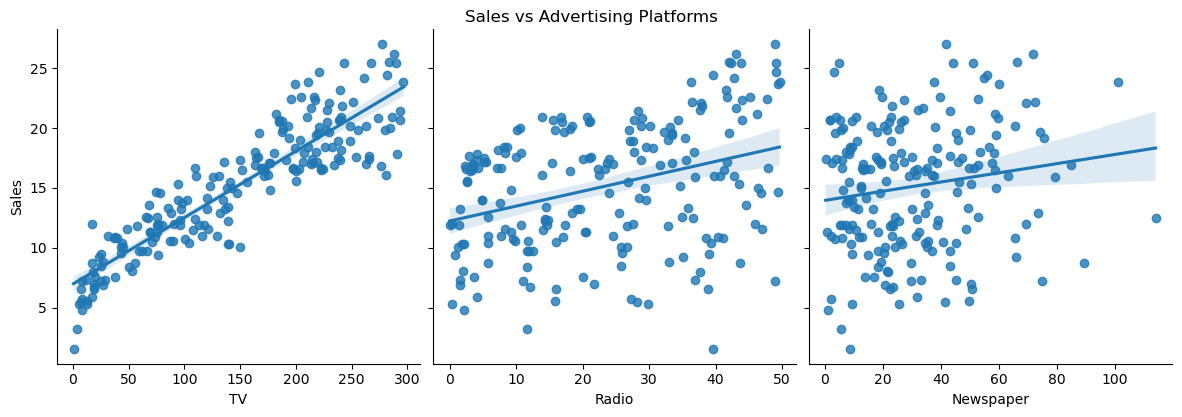

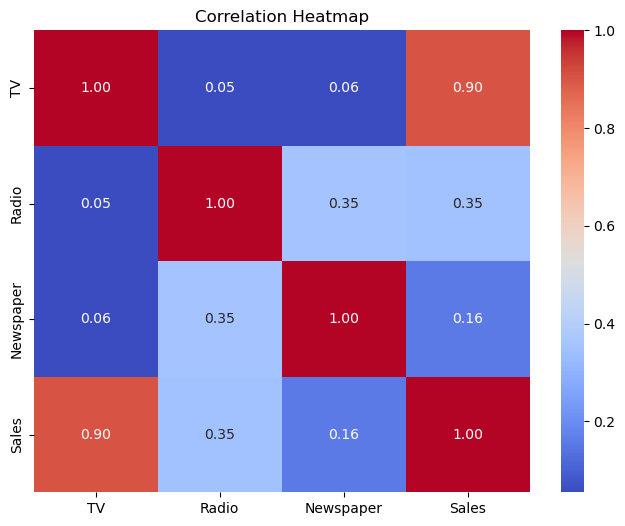


--- Model Performance Metrics ---
Mean Squared Error (MSE): 2.91
R-squared Score: 0.9059


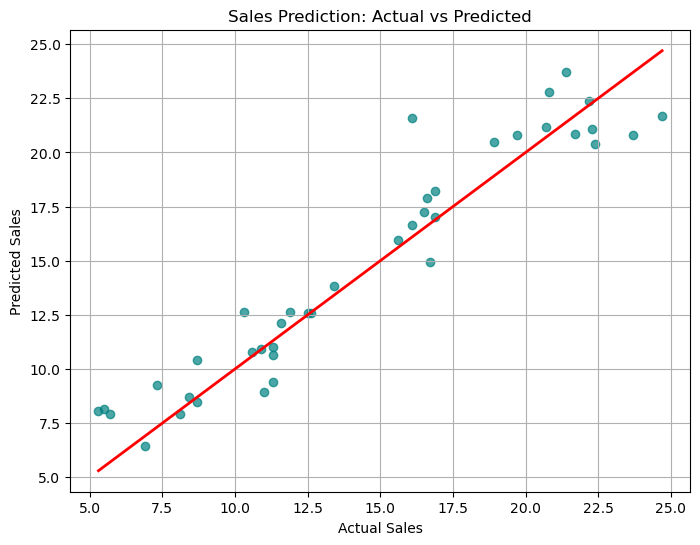

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. LOAD DATA DIRECTLY FROM GITHUB
# Using the raw URL for the standard Advertising dataset
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/advertising.csv"
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully from GitHub!")
except Exception as e:
    print(f"Error loading dataset: {e}")

# 2. DATA INSPECTION
print("\n--- Dataset Preview ---")
print(df.head())
# Drop 'Unnamed: 0' if present (index column from CSV)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# 3. EXPLORATORY DATA ANALYSIS (EDA)
# Visualizing relationships
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg')
plt.suptitle("Sales vs Advertising Platforms", y=1.02)
plt.show()

# Heatmap for Correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 4. PREPROCESSING
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. MODEL TRAINING
model = LinearRegression()
model.fit(X_train, y_train)

# 6. MODEL EVALUATION
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# 7. FINAL VISUALIZATION: ACTUAL VS PREDICTED
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Sales Prediction: Actual vs Predicted')
plt.grid(True)
plt.show()